# Imports

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

import xgboost as xgb
import shap

warnings.filterwarnings('ignore')

# Data Loading

In [6]:
# Memory-optimized dtypes
DTYPE_MAP = {
    'SK_ID_CURR': 'int32','TARGET': 'int8','CNT_CHILDREN': 'int8',
    'AMT_INCOME_TOTAL': 'float32','AMT_CREDIT': 'float32',
    'AMT_ANNUITY': 'float32','AMT_GOODS_PRICE': 'float32',
    'REGION_POPULATION_RELATIVE': 'float32','DAYS_BIRTH': 'int32',
    'DAYS_EMPLOYED': 'int32','DAYS_REGISTRATION': 'float32',
    'DAYS_ID_PUBLISH': 'int32','CNT_FAM_MEMBERS': 'float32',
    'EXT_SOURCE_1': 'float32','EXT_SOURCE_2': 'float32','EXT_SOURCE_3': 'float32'
}

df = pd.read_csv('application_train.csv', dtype=DTYPE_MAP, low_memory=False)

# Sanity Checks

In [7]:
# Basic validation
assert df['SK_ID_CURR'].duplicated().sum() == 0
missing = df.isnull().mean()

# Feature Engineering

In [8]:
def feature_engineering(df):
    df = df.copy()

    # Fix anomaly
    df['DAYS_EMPLOYED_ANOM'] = (df['DAYS_EMPLOYED'] == 365243).astype('int8')
    df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)

    # Convert to usable units
    df['AGE_YEARS'] = -df['DAYS_BIRTH'] / 365
    df['YEARS_EMPLOYED'] = -df['DAYS_EMPLOYED'] / 365

    # Financial ratios
    df['PAYMENT_RATE'] = df['AMT_ANNUITY'] / df['AMT_CREDIT']
    df['ANNUITY_INCOME_PERCENT'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']
    df['CREDIT_TO_GOODS_RATIO'] = df['AMT_CREDIT'] / df['AMT_GOODS_PRICE']

    # Income signals
    df['INCOME_PER_CHILD'] = df['AMT_INCOME_TOTAL'] / (1 + df['CNT_CHILDREN'])
    df['INCOME_PER_FAM_MEMBER'] = df['AMT_INCOME_TOTAL'] / df['CNT_FAM_MEMBERS'].replace(0,1)

    # External scores
    ext = ['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']
    df['EXT_SOURCES_MEAN'] = df[ext].mean(axis=1)
    df['EXT_SOURCES_PROD'] = df[ext].prod(axis=1)

    return df

df = feature_engineering(df)

# Feature Split

In [9]:
EXCLUDE = ['SK_ID_CURR','TARGET']

categorical = df.select_dtypes('object').columns.tolist()
numeric = [c for c in df.columns if c not in categorical + EXCLUDE]

# Preprocessing Pipeline

In [10]:
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, numeric),
    ('cat', cat_pipe, categorical)
])

# Train Test Split

In [11]:
X = df[numeric + categorical]
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [12]:
X_train.head()

,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,...,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE,WEEKDAY_APPR_PROCESS_START,ORGANIZATION_TYPE,FONDKAPREMONT_MODE,HOUSETYPE_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE
181648,2,90000.0,227520.0,13189.5,180000.0,0.008230,-12298,-946.0,-6378.0,-4670,...,Higher education,Married,House / apartment,Laborers,WEDNESDAY,Business Entity Type 2,reg oper account,block of flats,Panel,No
229245,0,90000.0,161730.0,13095.0,135000.0,0.003069,-15375,-92.0,-1292.0,-1994,...,Secondary / secondary special,Married,House / apartment,Drivers,TUESDAY,Other,NaN,NaN,NaN,NaN
122525,0,135000.0,728847.0,26307.0,553500.0,0.020713,-19307,-1646.0,-7951.0,-2842,...,Secondary / secondary special,Single / not married,House / apartment,Laborers,TUESDAY,Business Entity Type 3,reg oper spec account,block of flats,Panel,No
306311,0,135000.0,474183.0,34636.5,391500.0,0.011703,-17791,-1651.0,-1033.0,-1345,...,Secondary / secondary special,Single / not married,House / apartment,Laborers,TUESDAY,Business Entity Type 3,NaN,block of flats,Block,No
300658,0,180000.0,254700.0,27558.0,225000.0,0.006629,-8486,-977.0,-2873.0,-852,...,Incomplete higher,Single / not married,House / apartment,Accountants,MONDAY,Restaurant,NaN,NaN,NaN,NaN


# Preprocess

In [13]:
X_train_p = preprocessor.fit_transform(X_train)
X_test_p = preprocessor.transform(X_test)

# Model Training

In [14]:
# Handle imbalance
scale = (y_train==0).sum()/(y_train==1).sum()

model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,
    eval_metric='auc',
    early_stopping_rounds=30,
    n_jobs=-1
)

model.fit(X_train_p, y_train, eval_set=[(X_test_p, y_test)], verbose=False)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",30
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

# Evaluation

AUC: 0.7681179715791145
              precision    recall  f1-score   support

           0       0.96      0.74      0.84     56538
           1       0.18      0.66      0.28      4965

    accuracy                           0.73     61503
   macro avg       0.57      0.70      0.56     61503
weighted avg       0.90      0.73      0.79     61503



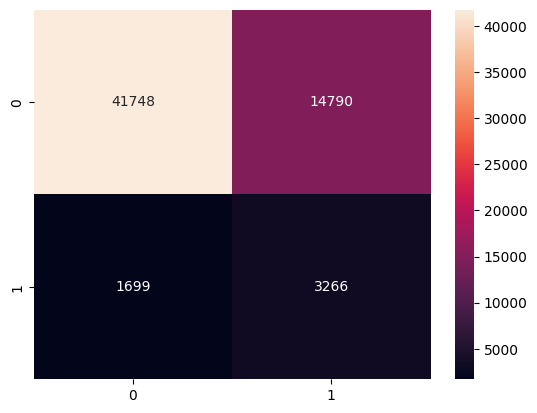

In [15]:
y_prob = model.predict_proba(X_test_p)[:,1]
y_pred = model.predict(X_test_p)

auc = roc_auc_score(y_test, y_prob)
print('AUC:', auc)
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

# SHAP Explainability

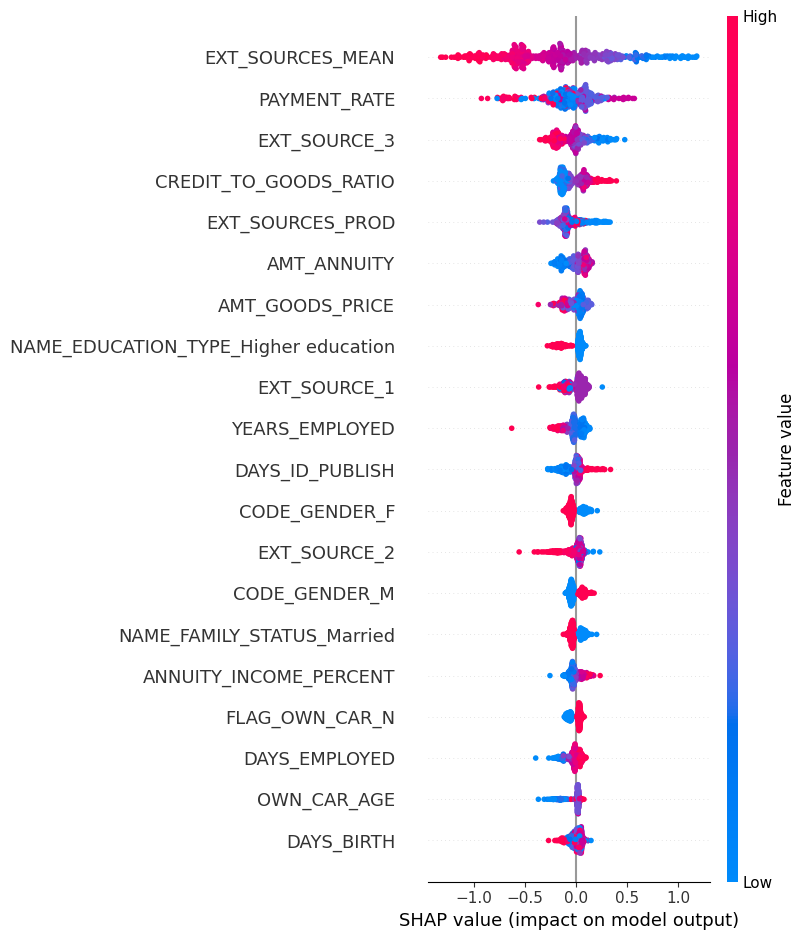

In [16]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_p[:500])

ohe_names = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical)
feature_names = numeric + list(ohe_names)

shap.summary_plot(shap_values, X_test_p[:500], feature_names=feature_names)

# Save Artifacts

In [17]:
joblib.dump(preprocessor, 'preprocessor.pkl')
joblib.dump(model, 'model.pkl')

['model.pkl']

In [22]:
X_train.to_csv("X_train_full.csv", index=False)
